Import the data

In [3]:
library(arrow)
library(tidyverse) # for data manipulation and visualization
library(patchwork) # for combining plots
library(here) # for file path management
library(ptw)
library(ggrepel)

#Tab one baseline correction
combinedWide <- read_parquet("../data/processed/combinedWide.parquet")
combinedWide <- combinedWide |> 
  mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))
combinedLong <- read_parquet("../data/processed/combinedLong.parquet")
combinedLong <- combinedLong |> 
  mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))

Functions

In [5]:
split_by_species <- function(df, species_col = "species") {
  split(df, df[[species_col]])
}


plot_by_time <- function(df, title_input = "Title") {
  df |> 
    filter(instrument == "DAD") |>
    mutate(sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  labs(
    title = title_input,
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))
  
}


wide_to_long <- function(df) {
  df |> 
    pivot_longer(
      cols = where(is.numeric),
      names_to = "time",
      values_to = "intensity"
    )
}

##############-----------------------Baseline-------------------------#######################
correct_baseline <- function(df, l = 1*10^9, meta_in = TRUE) {
  # keep metadata
  meta <- df |> select(time_point, species, sample, enzyme, instrument)
  
  # apply baseline correction only to numeric columns
  numeric_df <- df |> select(where(is.numeric))
  numeric_corrected <- baseline.corr(numeric_df, lambda = l, p = 0.001, eps = 1e-8)
  
  if (meta_in) {
  combined <- bind_cols(meta, numeric_corrected)
  return(combined)
  }
  return(numeric_corrected)
}
##############------------------------PCA-------------------------#######################
pca <- function(df, num_comp = 10, center_in = TRUE, scale_in = TRUE, scale_na = FALSE) {

  df <- df |> 
    mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))
  
  metadata <- df |> 
    select(!where(is.numeric))

  if (scale_na) {
  dataPCA <- df |>
    select(where(is.numeric)) |>
    mutate(across(
      everything(),
      ~ ifelse(is.na(.), min(., na.rm = TRUE) / 2, .)
    ))
  } else {
  dataPCA <- df |>
    select(where(is.numeric))
  }

  pca_res <- prcomp(dataPCA, center = center_in, scale. = scale_in)

  scores <- as.data.frame(pca_res$x[, 1:num_comp, drop = FALSE])
  scores <- bind_cols(metadata, scores)
  loadings <- as.data.frame(pca_res$rotation[, 1:num_comp, drop = FALSE])
  variance <- data.frame(variance = (pca_res$sdev^2) / sum(pca_res$sdev^2))

  list(
    df = df,
    scores = scores,
    loadings = loadings,
    variance = variance
  )
}

plot_scores <- function(scores, PC_first, PC_second, title_in = "", file_path = NULL) {

  PC_first  <- rlang::enquo(PC_first)
  PC_second <- rlang::enquo(PC_second)

  circle_df <- scores |> 
    group_by(species) |> 
    summarize(
      x0 = mean(!!PC_first, na.rm = TRUE),
      y0 = mean(!!PC_second, na.rm = TRUE),
      r = max(
        sqrt((!!PC_first - x0)^2 + (!!PC_second - y0)^2),
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  label_positions <- circle_df |> 
    mutate(
      dx = x0 / sqrt(x0^2 + y0^2),
      dy = y0 / sqrt(x0^2 + y0^2),
      x = x0 + dx * (r * 1.08),
      y = y0 + dy * (r * 1.08)
    )

  p <- ggplot(scores, aes(x = !!PC_first, y = !!PC_second)) +

    geom_point(
      aes(color = time_point, shape = species),
      size = 3
    ) +

    # geom_label(
    #   data = label_positions,
    #   aes(x = x, y = y, label = species),
    #   inherit.aes = FALSE,
    #   fill = "white",
    #   color = "black",
    #   size = 3,
    #   label.size = 0.25
    # ) +

    scale_color_viridis_d(
      option = "viridis",
      name = "Incubation Time"
    ) +

    labs(
      title = title_in,
      subtitle = "Colored by incubation time; species-level dispersion shown",
      x = rlang::as_label(PC_first),
      y = rlang::as_label(PC_second)
    ) +

    coord_equal() +
    theme_minimal()

  if (!missing(file_path) && !is.null(file_path)) {
  ggsave(
    filename = file_path,
    plot = last_plot(),
    dpi = 300,
    width = 8,
    height = 6,
    units = "in"
  )
  }
  return(p)
}

plot_loadings <- function(df, PC) {
  PC  <- rlang::enquo(PC)

  ggplot(df, aes(x = time, y = !!PC))+ 
  geom_line()+
  labs(title = "PCA Loadings Plot",
       x = "Time",
       y = rlang::as_label(PC)) +
  theme_minimal()
}

plot_scree <- function(df){
  df <- df |> 
  mutate(
    PC = factor(
      paste0("PC", row_number()),
      levels = paste0("PC", row_number())
    )
  )

  df_new <- df |> 
  mutate(cumulative = cumsum(variance)) |> 
  slice(1:10)
  
  ggplot(df_new, aes(x = PC, y = variance, group = 1)) +
  geom_line(linewidth = .7) +
  geom_point(size = 1) +
  geom_text(data = df_new |> slice(1:4),
            inherit.aes = FALSE,
            aes(x = PC, y = variance, label = paste0(round(cumulative*100), "%")), 
            vjust = -0.5, hjust = -.4, size = 3) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Scree Plot of Principal Components",
    x = "Principal Component",
    y = "Proportion of Variance Explained",
    caption = "Percentages indicate cumulative variance explained"
  ) +
  theme_minimal()
}

##############------------------------PTW-------------------------#######################
ptw_function <- function(df) {
  meta <- df |> 
    select(time_point, species, sample, enzyme, instrument)

  Num <- df |> select(where(is.numeric))

  reference_num <- Num[1, ]
  samples_num   <- Num[2:15, ]

  reference_meta <- meta[1, ]
  samples_meta   <- meta[2:15, ]

  res <- ptw(reference_num, samples_num, warp.type = "individual")

  warped_df <- as.data.frame(res$warped.sample)
  reference_df <- as.data.frame(res$reference)

  colnames(warped_df) <- colnames(reference_df)

  warped_full <- bind_cols(samples_meta, warped_df)
  reference_full <- bind_cols(reference_meta, reference_df)

  final_df <- bind_rows(reference_full, warped_full)

  return(final_df)
}

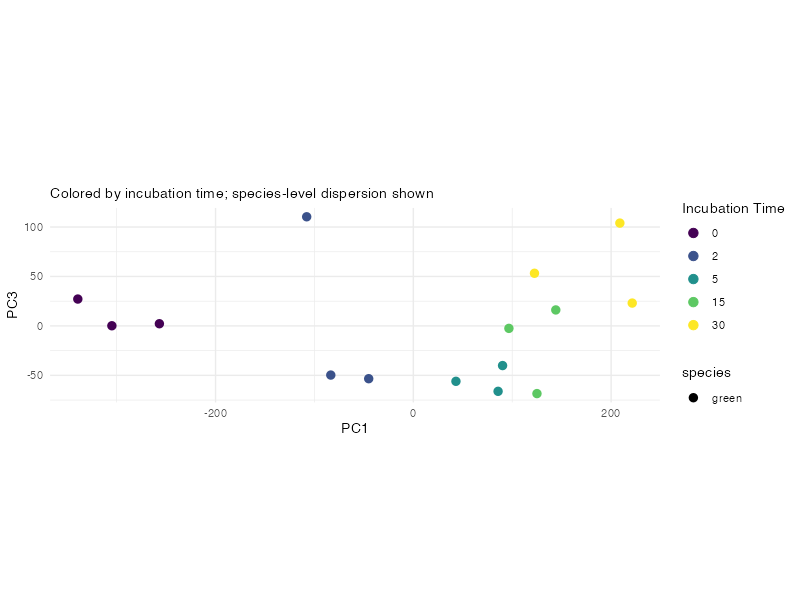

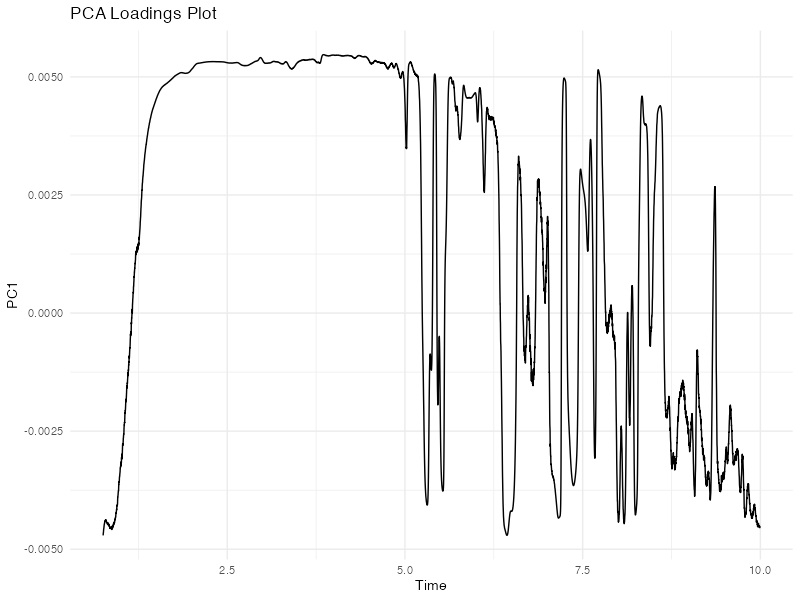

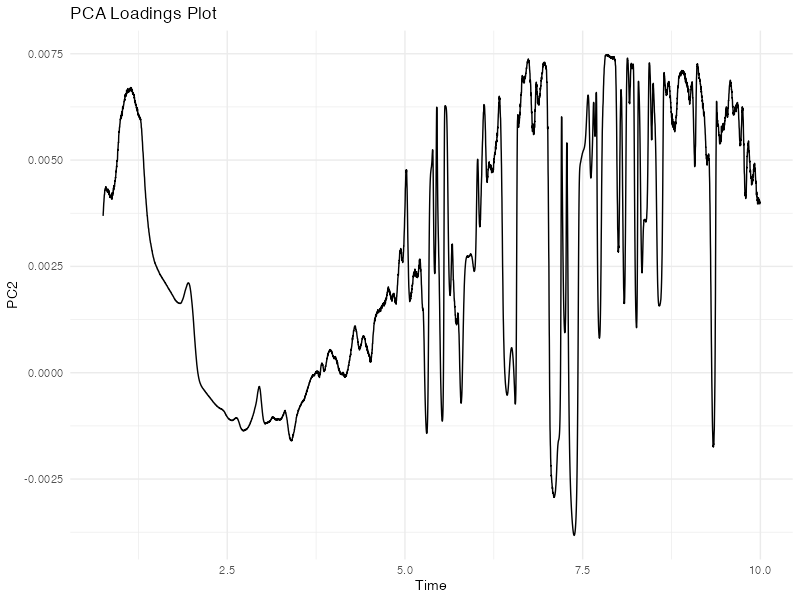

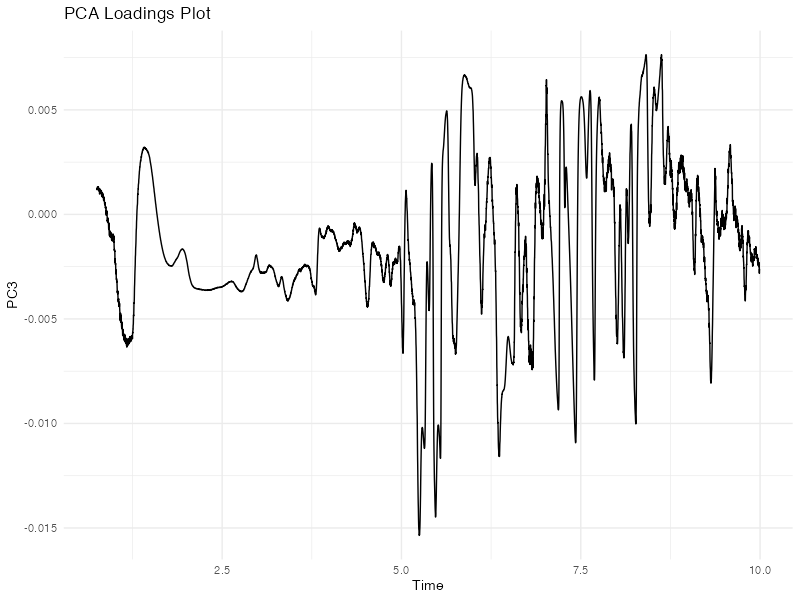

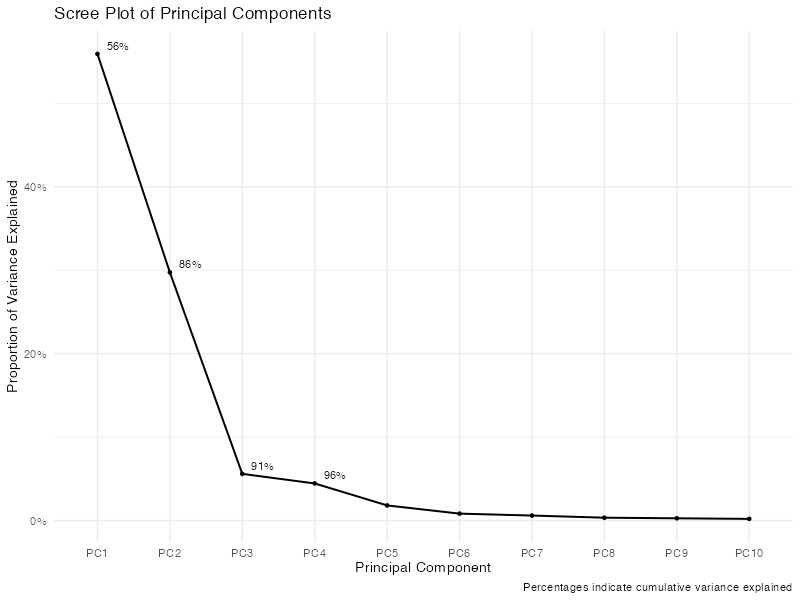

In [9]:
species_df <- split_by_species(combinedWide)

green <- species_df[['green']]
greenRes <- pca(green)

variance <- greenRes$variance
loadings <- as_tibble(greenRes$loadings, rownames = "time") |> 
  mutate(time = as.numeric(time))
scores <- greenRes$scores

plot_scores(scores, PC1, PC3)
plot_loadings(loadings, PC1)
plot_loadings(loadings, PC2)
plot_loadings(loadings, PC3)
plot_scree(variance)

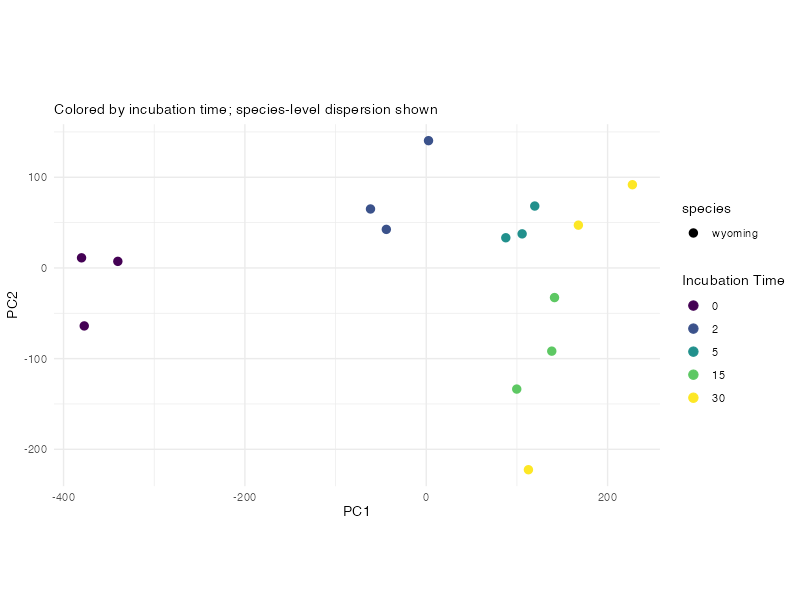

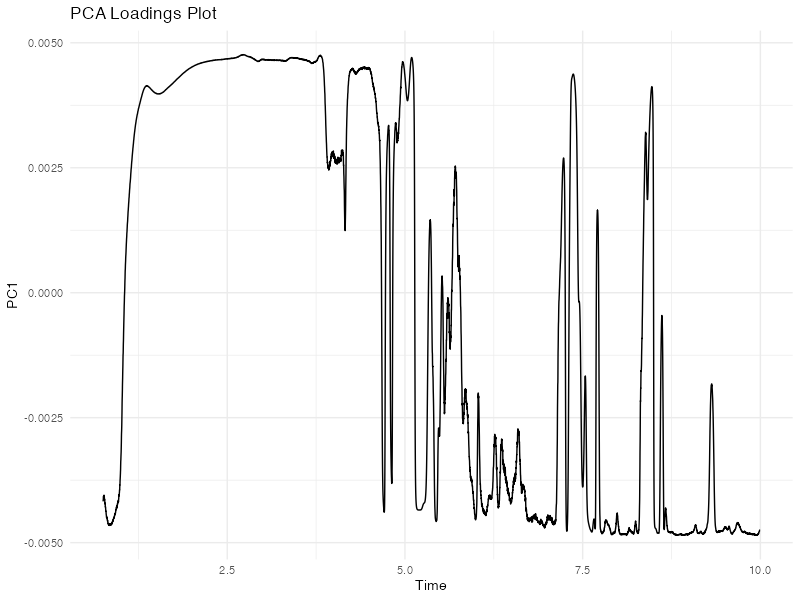

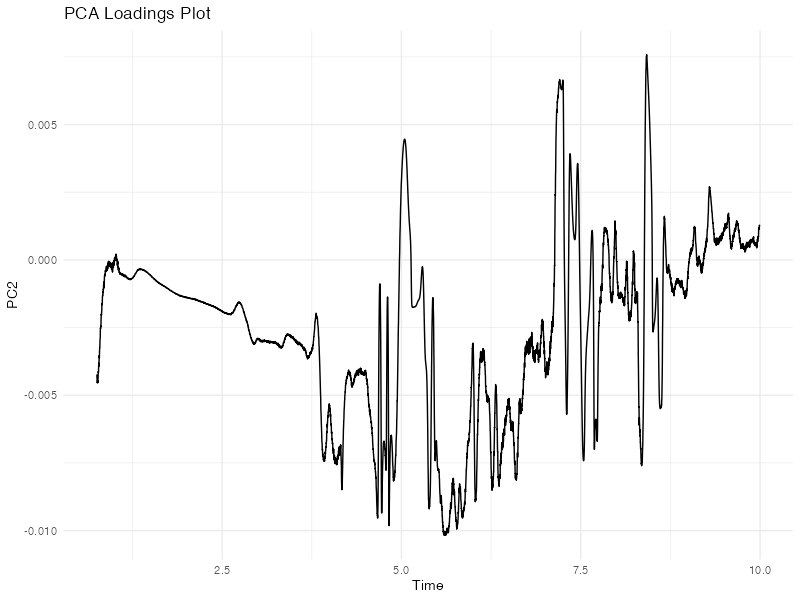

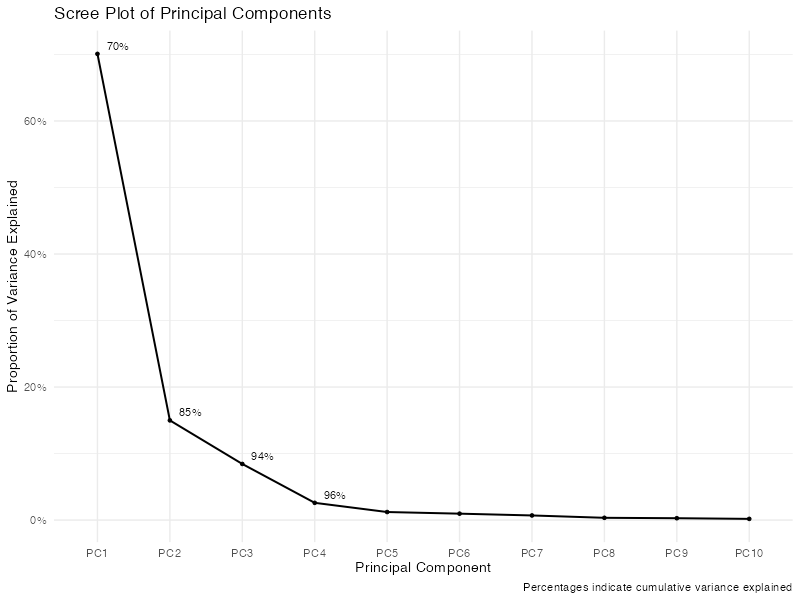

In [11]:
species_df <- split_by_species(combinedWide)

wyoming <- species_df[['wyoming']]
#wyoming <- correct_baseline(wyoming, meta_in = TRUE)
wyomingRes <- pca(wyoming)

variance <- wyomingRes$variance
loadings <- as_tibble(wyomingRes$loadings, rownames = "time") |> 
  mutate(time = as.numeric(time))
scores <- wyomingRes$scores

plot_scores(scores, PC1, PC2)
plot_loadings(loadings, PC1)
plot_loadings(loadings, PC2)
plot_scree(variance)